## House Price Prediction

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, ParameterGrid

In [5]:
#set scientific notation to full number
pd.set_option('display.float_format', '{:.0f}'.format)

## Exploratory Data Analysis

In [6]:
df = pd.read_csv("House_Rent_Dataset.csv")

In [132]:
df_copy = df.copy()

In [133]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [134]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


In [135]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746,4746,4746,4746
mean,2,34993,967,2
std,1,78106,634,1
min,1,1200,10,1
25%,2,10000,550,1
50%,2,16000,850,2
75%,3,33000,1200,2
max,6,3500000,8000,10


In [136]:
df.columns = [col.lower().replace(" ","_") for col in df.columns]

In [137]:
df.isna().sum()

posted_on            0
bhk                  0
rent                 0
size                 0
floor                0
area_type            0
area_locality        0
city                 0
furnishing_status    0
tenant_preferred     0
bathroom             0
point_of_contact     0
dtype: int64

## Outlier Checking

In [138]:
df['rent'].quantile([0.90, 0.95, 0.99])

1    72000
1   130000
1   300000
Name: rent, dtype: float64

In [139]:
df['rent'].sort_values(ascending=False).head()

1837    3500000
1001    1200000
827     1000000
1329     850000
1459     700000
Name: rent, dtype: int64

### Transform 'rent' into log. And then make a interquartile range to capping oulier.

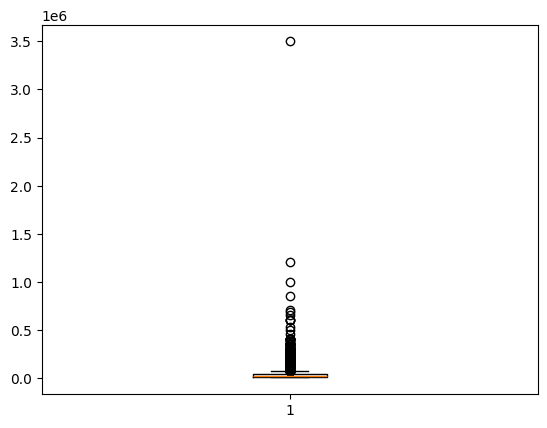

In [140]:
plt.boxplot(df['rent'])
plt.show()

<Axes: xlabel='rent'>

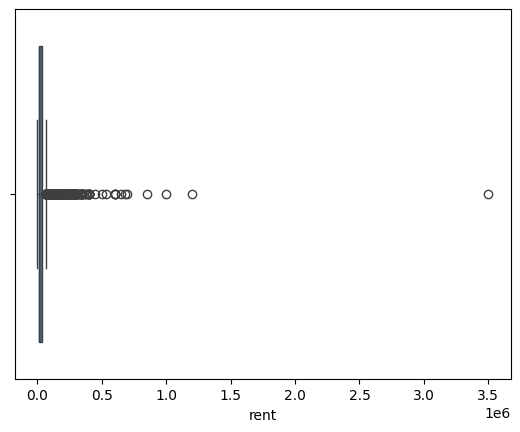

In [141]:
sns.boxplot(x=df['rent'])

In [142]:
#log transform
df['rent'] = np.log1p(df['rent'])

<Axes: xlabel='rent'>

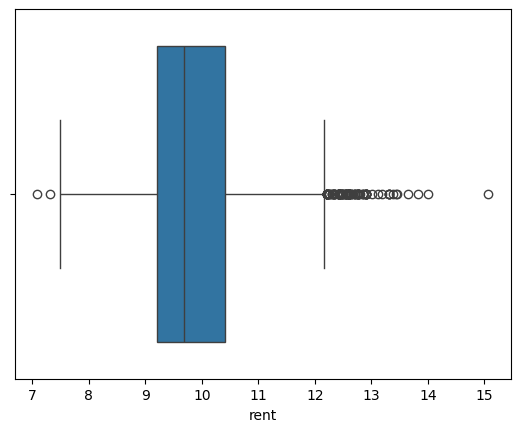

In [143]:
sns.boxplot(x=df['rent'])

In [144]:
# Outlier Detect with IQR

q1 = df['rent'].quantile(0.25)
q3 = df['rent'].quantile(0.75)

iqr = q3-q1

upper = q3+1.5*iqr
lower = q1-1.5*iqr

# df = df[(df['rent']>=lower) & (df['rent']<=upper)]
df['rent'] = df['rent'].clip(lower, upper) #capping the values to control extreme values

## Feature Engineering

In [145]:
df.head(5)

,posted_on,bhk,rent,size,floor,area_type,area_locality,city,furnishing_status,tenant_preferred,bathroom,point_of_contact
0,2022-05-18,2,9,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,10,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,10,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,9,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,9,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [146]:
print(df['floor'].unique())

<StringArray>
[ 'Ground out of 2',       '1 out of 3',       '1 out of 2',
  'Ground out of 1',  'Ground out of 4',       '1 out of 4',
       '1 out of 1',  'Ground out of 3',       '2 out of 3',
       '4 out of 5',
 ...
      '4 out of 26',     '24 out of 33',      '4 out of 17',
      '1 out of 35',     '11 out of 35', 'Ground out of 15',
 'Ground out of 27',     '15 out of 30',     '12 out of 30',
     '23 out of 34']
Length: 480, dtype: str


In [147]:
df['floor'] = df['floor'].str.replace("Ground", "0")  

In [148]:
df['floor'].unique()

<StringArray>
[  '0 out of 2',   '1 out of 3',   '1 out of 2',   '0 out of 1',
   '0 out of 4',   '1 out of 4',   '1 out of 1',   '0 out of 3',
   '2 out of 3',   '4 out of 5',
 ...
  '4 out of 26', '24 out of 33',  '4 out of 17',  '1 out of 35',
 '11 out of 35',  '0 out of 15',  '0 out of 27', '15 out of 30',
 '12 out of 30', '23 out of 34']
Length: 480, dtype: str

In [149]:
df[['living_floor', 'total_floor']] = df['floor'].str.split(' out of ', expand=True)

In [150]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   posted_on          4746 non-null   str    
 1   bhk                4746 non-null   int64  
 2   rent               4746 non-null   float64
 3   size               4746 non-null   int64  
 4   floor              4746 non-null   str    
 5   area_type          4746 non-null   str    
 6   area_locality      4746 non-null   str    
 7   city               4746 non-null   str    
 8   furnishing_status  4746 non-null   str    
 9   tenant_preferred   4746 non-null   str    
 10  bathroom           4746 non-null   int64  
 11  point_of_contact   4746 non-null   str    
 12  living_floor       4746 non-null   str    
 13  total_floor        4742 non-null   str    
dtypes: float64(1), int64(3), str(10)
memory usage: 519.2 KB


In [151]:
df['living_floor'].unique()

<StringArray>
[             '0',              '1',              '2',              '4',
              '3',              '5',              '7',              '8',
 'Upper Basement',             '11', 'Lower Basement',              '6',
             '14',             '43',             '13',             '18',
             '17',              '9',             '19',             '60',
             '34',             '12',             '26',             '25',
             '53',             '16',             '10',             '39',
             '32',             '47',             '28',             '20',
             '15',             '65',             '40',             '37',
             '22',             '21',             '30',             '35',
             '33',             '44',             '41',             '46',
             '27',             '45',             '48',             '50',
             '24',             '23',             '29',             '49',
             '36',             '76']


In [152]:
df['living_floor'] = df['living_floor'].str.replace({
    'Lower Basement':'-2',
    'Upper Basement':'-1'
})

In [153]:
df['living_floor'].unique()

<StringArray>
[ '0',  '1',  '2',  '4',  '3',  '5',  '7',  '8', '-1', '11', '-2',  '6', '14',
 '43', '13', '18', '17',  '9', '19', '60', '34', '12', '26', '25', '53', '16',
 '10', '39', '32', '47', '28', '20', '15', '65', '40', '37', '22', '21', '30',
 '35', '33', '44', '41', '46', '27', '45', '48', '50', '24', '23', '29', '49',
 '36', '76']
Length: 54, dtype: str

In [154]:
df['total_floor'].unique()

<StringArray>
[ '2',  '3',  '1',  '4',  '5', '14',  '8',  '6', '19', '10',  '7', '13', '78',
 '18', '12', '24', '31', '21', '23', '20',  '9', '22', '58', '16', '66', '48',
 '40', '44', '42', '41', '60', '32', '30', '29', '89', '15', '11', '28', '17',
 '45', '35', '75', '38', '51', '43', '25', '27', '26', '76', '36', '37', '55',
 '68', '77', '50', '59', '62', '39', '52', '54', '33', '46', '85', '71', '81',
 '34',  nan]
Length: 67, dtype: str

In [155]:
df[df['total_floor'].isna()]

,posted_on,bhk,rent,size,floor,area_type,area_locality,city,furnishing_status,tenant_preferred,bathroom,point_of_contact,living_floor,total_floor
2553,2022-06-18,2,10,400,3,Super Area,"Kasturba Niketan, Lajpat Nagar 2",Delhi,Unfurnished,Bachelors/Family,1,Contact Owner,3,NaN
2883,2022-05-23,1,10,450,0,Carpet Area,"DDA Flat AD Block, Shalimar Bagh AD Block",Delhi,Furnished,Bachelors/Family,1,Contact Owner,0,NaN
4490,2022-06-12,3,10,900,1,Super Area,"Malakpet, NH 9",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner,1,NaN
4560,2022-05-31,3,10,1270,1,Carpet Area,Tarnaka,Hyderabad,Furnished,Family,2,Contact Owner,1,NaN


In [156]:
df.head(3)

,posted_on,bhk,rent,size,floor,area_type,area_locality,city,furnishing_status,tenant_preferred,bathroom,point_of_contact,living_floor,total_floor
0,2022-05-18,2,9,1100,0 out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,0,2
1,2022-05-13,2,10,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,1,3
2,2022-05-16,2,10,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,1,3


In [157]:
df.dropna(subset=['total_floor'], inplace=True)

In [158]:
df.info()

<class 'pandas.DataFrame'>
Index: 4742 entries, 0 to 4745
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   posted_on          4742 non-null   str    
 1   bhk                4742 non-null   int64  
 2   rent               4742 non-null   float64
 3   size               4742 non-null   int64  
 4   floor              4742 non-null   str    
 5   area_type          4742 non-null   str    
 6   area_locality      4742 non-null   str    
 7   city               4742 non-null   str    
 8   furnishing_status  4742 non-null   str    
 9   tenant_preferred   4742 non-null   str    
 10  bathroom           4742 non-null   int64  
 11  point_of_contact   4742 non-null   str    
 12  living_floor       4742 non-null   str    
 13  total_floor        4742 non-null   str    
dtypes: float64(1), int64(3), str(10)
memory usage: 555.7 KB


In [159]:
df['living_floor'] = df['living_floor'].astype(int)
df['total_floor'] = df['total_floor'].astype(int)

In [160]:
#unique value of frequency
df['area_locality'].value_counts().unique()

array([37, 29, 24, 22, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,  9,  8,
        7,  6,  5,  4,  3,  2,  1])

In [161]:
#unique elements number in this field
df['area_locality'].nunique()

2233

In [162]:
df['area_locality'].value_counts()

area_locality
Bandra West                     37
Gachibowli                      29
Electronic City                 24
Velachery                       22
Miyapur, NH 9                   22
                                ..
Saket, Secunderabad              1
Vinayaka Nagar                   1
BN Reddy Nagar                   1
Godavari Homes, Quthbullapur     1
Manikonda, Hyderabad             1
Name: count, Length: 2233, dtype: int64

## Correlation Examination

In [163]:
df.info()

<class 'pandas.DataFrame'>
Index: 4742 entries, 0 to 4745
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   posted_on          4742 non-null   str    
 1   bhk                4742 non-null   int64  
 2   rent               4742 non-null   float64
 3   size               4742 non-null   int64  
 4   floor              4742 non-null   str    
 5   area_type          4742 non-null   str    
 6   area_locality      4742 non-null   str    
 7   city               4742 non-null   str    
 8   furnishing_status  4742 non-null   str    
 9   tenant_preferred   4742 non-null   str    
 10  bathroom           4742 non-null   int64  
 11  point_of_contact   4742 non-null   str    
 12  living_floor       4742 non-null   int64  
 13  total_floor        4742 non-null   int64  
dtypes: float64(1), int64(5), str(8)
memory usage: 555.7 KB


## Ordinal Encoding

In [164]:
df['furnishing_status'].unique()

<StringArray>
['Unfurnished', 'Semi-Furnished', 'Furnished']
Length: 3, dtype: str

In [165]:
furnish_map = {
    'Unfurnished':0,
    'Semi-Furnished':1,
    'Furnished':2
}

In [166]:
df['furnishing_status'] = df['furnishing_status'].map(furnish_map)

## Feature Experiment

In [167]:
df = pd.get_dummies(df, columns=['tenant_preferred', 'area_type'], drop_first=True)

In [168]:
# area_locality + groupping
top_localities = df['area_locality'].value_counts().nlargest(50).index

df['area_locality'] = df['area_locality'].apply(lambda x: x if x in top_localities else 'other')


In [169]:
df['area_locality'].unique()

<StringArray>
[                                   'other',
                  'Salt Lake City Sector 2',
                                   'Behala',
                                    'Kasba',
                  'Salt Lake City Sector 1',
                  'Salt Lake City Sector 5',
                              'Bandra West',
                            'Goregaon West',
                                  'Chembur',
                                'Khar West',
                             'Andheri West',
                         'Ramamurthy Nagar',
 'Electronic City Phase 2, Electronic City',
                                   'Hebbal',
              'Jp Nagar Phase 7, J P Nagar',
                             'Mahadevapura',
                                'K R Puram',
                          'Electronic City',
                               'whitefield',
                              'Vijayanagar',
              'Murugeshpalya, Airport Road',
                'kst chattarpur Apartment

In [170]:
df = pd.get_dummies(df, columns=['area_locality'], drop_first=True)

In [171]:
df.head(3)

,posted_on,bhk,rent,size,floor,city,furnishing_status,bathroom,point_of_contact,living_floor,...,area_locality_Salt Lake City Sector 5,area_locality_Sholinganallur,area_locality_Vadapalani,"area_locality_Valasaravakkam, Arcot Road",area_locality_Vasant Kunj,area_locality_Velachery,area_locality_Vijayanagar,area_locality_kst chattarpur Apartments,area_locality_other,area_locality_whitefield
0,2022-05-18,2,9,1100,0 out of 2,Kolkata,0,2,Contact Owner,0,...,False,False,False,False,False,False,False,False,True,False
1,2022-05-13,2,10,800,1 out of 3,Kolkata,1,1,Contact Owner,1,...,False,False,False,False,False,False,False,False,True,False
2,2022-05-16,2,10,1000,1 out of 3,Kolkata,1,1,Contact Owner,1,...,False,False,False,False,False,False,False,False,False,False


In [172]:
feature_columns = df.select_dtypes(include=['int64','bool', 'float64']).columns

In [173]:
df[feature_columns].info()

<class 'pandas.DataFrame'>
Index: 4742 entries, 0 to 4745
Data columns (total 61 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   bhk                                                     4742 non-null   int64  
 1   rent                                                    4742 non-null   float64
 2   size                                                    4742 non-null   int64  
 3   furnishing_status                                       4742 non-null   int64  
 4   bathroom                                                4742 non-null   int64  
 5   living_floor                                            4742 non-null   int64  
 6   total_floor                                             4742 non-null   int64  
 7   tenant_preferred_Bachelors/Family                       4742 non-null   bool   
 8   tenant_preferred_Family                               

In [174]:
scaler = StandardScaler()

In [175]:
X = df[feature_columns].drop('rent', axis=1)
y = df['rent']

In [176]:
X_train, X_temp, y_train, y_temp = train_test_split(X,y, test_size=0.3, random_state=42)

In [177]:
X_temp, X_test, y_temp, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [178]:
X_train_scaled = scaler.fit_transform(X_train)
X_temp_scaled = scaler.transform(X_temp)
X_test_scaled = scaler.transform(X_test)

In [179]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [180]:
#Validation prediction
y_val_pred = model.predict(X_temp_scaled)

In [181]:
#Test prediction
y_test_pred = model.predict(X_test_scaled)

In [182]:
#Validation Score
print(f"Linear Validation Score: {root_mean_squared_error(y_temp, y_val_pred)}")
print(f"Linear Validation R2: {r2_score(y_temp, y_val_pred)}")

Linear Validation Score: 0.50782796844386
Linear Validation R2: 0.7022578924587944


In [183]:
print(f"Linear Test Score: {root_mean_squared_error(y_test, y_test_pred)}")
print(f"Linear Test r2: {r2_score(y_test, y_test_pred)}")

Linear Test Score: 0.513060414684655
Linear Test r2: 0.6827261283645896


In [184]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [185]:
y_val_predict = ridge.predict(X_temp_scaled)
y_test_predict = ridge.predict(X_test_scaled)

In [186]:
print(f"Ridge Validation Score: {root_mean_squared_error(y_temp, y_val_predict)}")
print(f"Ridge Validation r2: {r2_score(y_temp, y_val_predict)}")

Ridge Validation Score: 0.5076897841377394
Ridge Validation r2: 0.7024199067288652


In [187]:
print(f"Ridge Test Score: {root_mean_squared_error(y_test, y_test_predict)}")
print(f"Ridge Test r2: {r2_score(y_test, y_test_predict)}")

Ridge Test Score: 0.5130495747966343
Ridge Test r2: 0.6827395348828488


In [188]:
pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)

area_type_Carpet Area                                     0
total_floor                                               0
bathroom                                                  0
area_type_Super Area                                      0
size                                                      0
area_locality_Bandra West                                 0
furnishing_status                                         0
bhk                                                       0
area_locality_other                                       0
area_locality_Andheri West                                0
area_locality_Khar West                                   0
area_locality_Chembur                                     0
area_locality_Vasant Kunj                                 0
area_locality_Banjara Hills, NH 9                         0
area_locality_Goregaon West                               0
area_locality_Salt Lake City Sector 2                     0
area_locality_Madhapur                  

In [189]:
from sklearn.ensemble import RandomForestRegressor

In [190]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [191]:
y_val_rf = rf.predict(X_temp)
y_test_rf = rf.predict(X_test)

In [192]:
print(f"Random forest Validation Score: {root_mean_squared_error(y_temp, y_val_rf)}")
print(f"Random forest Validation r2: {r2_score(y_temp, y_val_rf)}")

Random forest Validation Score: 0.46135334106778525
Random forest Validation r2: 0.7542608415455428


In [193]:
print(f"Random forest Test Score: {root_mean_squared_error(y_test, y_test_rf)}")
print(f"Random forest Test r2: {r2_score(y_test, y_test_rf)}")

Random forest Test Score: 0.49005952447528445
Random forest Test r2: 0.7105357320993833


In [194]:
from xgboost import XGBRegressor

In [195]:
xgb = XGBRegressor(
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth = 5,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42
)

In [196]:
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [197]:
y_val_xgb = xgb.predict(X_temp)
y_test_xgb = xgb.predict(X_test)

In [198]:
print("XGBoost Validation RMSE:", root_mean_squared_error(y_temp, y_val_xgb))
print("XGBoost Validation R2:", r2_score(y_temp, y_val_xgb))

print("XGBoost Test RMSE:", root_mean_squared_error(y_test, y_test_xgb))
print("XGBoost Test R2:", r2_score(y_test, y_test_xgb))


XGBoost Validation RMSE: 0.438407144594006
XGBoost Validation R2: 0.778097460331049
XGBoost Test RMSE: 0.466024817265806
XGBoost Test R2: 0.7382327067857299


In [199]:
from sklearn.model_selection import GridSearchCV

In [200]:
param_grid = {
    'n_estimators': [200,300,400,500],
    'max_depth':[4,5,6,7],
    'learning_rate':[0.01, 0.05, 0.1],
    'subsample':[0.7, 0.8, 0.9],
    'colsample_bytree':[0.7, 0.8, 0.9]
}

In [201]:
xgb_gc = XGBRegressor(random_state=42)

grid = GridSearchCV(
    estimator=xgb_gc,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=1
)

In [202]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 5, ...], 'n_estimators': [200, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fol

In [203]:
print(f"Best Parameters: {grid.best_params_}")
print(f"Best CV Score: {grid.best_score_}")

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.9}
Best CV Score: 0.7428453158373848


In [204]:
best_xgb = grid.best_estimator_

y_val_pred = best_xgb.predict(X_temp)
y_test_pred = best_xgb.predict(X_test)

print("Validation R2:", r2_score(y_temp, y_val_pred))
print("Test R2:", r2_score(y_test, y_test_pred))


Validation R2: 0.775729236040328
Test R2: 0.7386353667982467


## Lets apply Target Encoding on copy dataset and then try it with XGBoost Model on best parameters.

In [205]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


In [206]:
df_original = df_copy.copy()

In [207]:
df_copy.columns = df_copy.columns.str.lower()

In [208]:
df_copy.columns = [col.replace(" ","_") for col in df_copy.columns]

In [209]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   posted_on          4746 non-null   str  
 1   bhk                4746 non-null   int64
 2   rent               4746 non-null   int64
 3   size               4746 non-null   int64
 4   floor              4746 non-null   str  
 5   area_type          4746 non-null   str  
 6   area_locality      4746 non-null   str  
 7   city               4746 non-null   str  
 8   furnishing_status  4746 non-null   str  
 9   tenant_preferred   4746 non-null   str  
 10  bathroom           4746 non-null   int64
 11  point_of_contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


In [210]:
#log transform to target varibale normalize the data.
df_copy['rent'] = np.log1p(df_copy['rent'])

In [211]:
#outlier detect with IQR

q1 = df_copy['rent'].quantile(0.25)
q3 = df_copy['rent'].quantile(0.75)

iqr = q3-q1

upper_c = q3+1.5*iqr
lower_c = q1-1.5*iqr

df_copy['rent'] = df_copy['rent'].clip(lower_c, upper_c)

In [212]:
df_copy['floor'] = df_copy['floor'].str.replace("Ground", "0")

In [213]:
df_copy[['living_floor', 'total_floor']] = df_copy['floor'].str.split(' out of ', expand=True)

In [214]:
df_copy['living_floor'].unique()

<StringArray>
[             '0',              '1',              '2',              '4',
              '3',              '5',              '7',              '8',
 'Upper Basement',             '11', 'Lower Basement',              '6',
             '14',             '43',             '13',             '18',
             '17',              '9',             '19',             '60',
             '34',             '12',             '26',             '25',
             '53',             '16',             '10',             '39',
             '32',             '47',             '28',             '20',
             '15',             '65',             '40',             '37',
             '22',             '21',             '30',             '35',
             '33',             '44',             '41',             '46',
             '27',             '45',             '48',             '50',
             '24',             '23',             '29',             '49',
             '36',             '76']


In [215]:
df_copy['living_floor'] = df_copy['living_floor'].str.replace({
    'Upper Basement':'-1',
    'Lower Basement':'-2'
})

In [216]:
df_copy['total_floor'].isna().sum()

np.int64(4)

In [217]:
df_copy.dropna(subset=['total_floor'], inplace=True)

In [218]:
df_copy['living_floor'].unique()

<StringArray>
[ '0',  '1',  '2',  '4',  '3',  '5',  '7',  '8', '-1', '11', '-2',  '6', '14',
 '43', '13', '18', '17',  '9', '19', '60', '34', '12', '26', '25', '53', '16',
 '10', '39', '32', '47', '28', '20', '15', '65', '40', '37', '22', '21', '30',
 '35', '33', '44', '41', '46', '27', '45', '48', '50', '24', '23', '29', '49',
 '36', '76']
Length: 54, dtype: str

In [219]:
df_copy['living_floor'] = df_copy['living_floor'].astype(int)
df_copy['total_floor'] = df_copy['total_floor'].astype(int)

In [220]:
df_copy['floor_ratio'] = df_copy['living_floor']/df_copy['total_floor']
df_copy['size_per_bhk'] = df_copy['size']/df_copy['bhk']
df_copy['bathroom_per_room'] = df_copy['bathroom']/df_copy['bhk']

## Cross Validation Encoding with Smoothing to prevent data leakage

In [221]:
from category_encoders import TargetEncoder
from sklearn.model_selection import KFold

In [222]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 4742 entries, 0 to 4745
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   posted_on          4742 non-null   str    
 1   bhk                4742 non-null   int64  
 2   rent               4742 non-null   float64
 3   size               4742 non-null   int64  
 4   floor              4742 non-null   str    
 5   area_type          4742 non-null   str    
 6   area_locality      4742 non-null   str    
 7   city               4742 non-null   str    
 8   furnishing_status  4742 non-null   str    
 9   tenant_preferred   4742 non-null   str    
 10  bathroom           4742 non-null   int64  
 11  point_of_contact   4742 non-null   str    
 12  living_floor       4742 non-null   int64  
 13  total_floor        4742 non-null   int64  
 14  floor_ratio        4742 non-null   float64
 15  size_per_bhk       4742 non-null   float64
 16  bathroom_per_room  4742 non-null   float

In [223]:
def cv_target_encoding(X, y, cols, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    X_enc = X.copy()
    for col in cols:
        X_enc[col] = np.nan

        for train_idx, val_idx in kf.split(X):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr = y.iloc[train_idx]

            #smoothing apply here
            te = TargetEncoder(cols=[col], smoothing=10)

            #mapping learn--only fold train
            te.fit(X_tr[[col]], y_tr)

            #apply on fold val
            X_enc.iloc[val_idx, X.columns.get_loc(col)] = te.transform(
                X_val[[col]]
            )[col]

    return X_enc

In [224]:
df_copy['tenant_preferred'].unique()

<StringArray>
['Bachelors/Family', 'Bachelors', 'Family']
Length: 3, dtype: str

In [225]:
df_copy['is_bachelors_allowed'] = df_copy['tenant_preferred'].apply(lambda x: 1 if 'Bachelors' in x else 0)
df_copy['is_family_allowed'] = df_copy['tenant_preferred'].apply(lambda x: 1 if 'Family' in x else 0)

In [226]:
# df_copy = pd.get_dummies(df_copy, columns=['furnishing_status'], drop_first=True)
# df_copy = pd.get_dummies(df_copy, columns=['city'], drop_first=True)

In [227]:
X = df_copy.drop('rent', axis=1)
y = df_copy['rent']

In [228]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y , test_size=0.3, random_state=42)
X_temp, X_test, y_temp, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

## One Hot Encoding before split is not ideal. It is not a big leakage but future space already become future aware.

In [229]:
cols = ['area_locality']

In [230]:
X_temp_enc = X_temp.copy()
X_test_enc = X_test.copy()

In [231]:
X_train_enc = cv_target_encoding(X_train, y_train, cols)

#fit full encoder
te_full = TargetEncoder(cols=cols, smoothing=10)
te_full.fit(X_train[cols], y_train)

X_temp_enc[cols] = te_full.transform(X_temp[cols])
X_test_enc[cols] = te_full.transform(X_test[cols])

In [232]:
#one hot encoding
X_train_enc = pd.get_dummies(X_train_enc, columns=['city', 'area_type'], drop_first=True)
X_temp_enc = pd.get_dummies(X_temp_enc, columns=['city', 'area_type'], drop_first=True)
X_test_enc = pd.get_dummies(X_test_enc, columns=['city','area_type'], drop_first=True)

In [233]:
X_temp_enc = X_temp_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

In [234]:
X_train_enc.info()

<class 'pandas.DataFrame'>
Index: 3319 entries, 3437 to 860
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   posted_on              3319 non-null   str    
 1   bhk                    3319 non-null   int64  
 2   size                   3319 non-null   int64  
 3   floor                  3319 non-null   str    
 4   area_locality          3319 non-null   float64
 5   furnishing_status      3319 non-null   str    
 6   tenant_preferred       3319 non-null   str    
 7   bathroom               3319 non-null   int64  
 8   point_of_contact       3319 non-null   str    
 9   living_floor           3319 non-null   int64  
 10  total_floor            3319 non-null   int64  
 11  floor_ratio            3319 non-null   float64
 12  size_per_bhk           3319 non-null   float64
 13  bathroom_per_room      3319 non-null   float64
 14  is_bachelors_allowed   3319 non-null   int64  
 15  is_family_allowed 

In [235]:
feature_columns = X_train_enc.select_dtypes(include=['int64', 'float64', 'bool']).columns

In [236]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 3319 entries, 3437 to 860
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   posted_on             3319 non-null   str    
 1   bhk                   3319 non-null   int64  
 2   size                  3319 non-null   int64  
 3   floor                 3319 non-null   str    
 4   area_type             3319 non-null   str    
 5   area_locality         3319 non-null   str    
 6   city                  3319 non-null   str    
 7   furnishing_status     3319 non-null   str    
 8   tenant_preferred      3319 non-null   str    
 9   bathroom              3319 non-null   int64  
 10  point_of_contact      3319 non-null   str    
 11  living_floor          3319 non-null   int64  
 12  total_floor           3319 non-null   int64  
 13  floor_ratio           3319 non-null   float64
 14  size_per_bhk          3319 non-null   float64
 15  bathroom_per_room     3319 non-null

In [237]:
from sklearn.ensemble import RandomForestRegressor

In [238]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_enc[feature_columns], y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [239]:
y_val_rf = rf.predict(X_temp_enc[feature_columns])
y_test_rf = rf.predict(X_test_enc[feature_columns])

In [240]:
print(f"Validation Score(Random Forest): {mean_squared_error(y_temp, y_val_rf)}")
print(f"Validation MAE: {mean_absolute_error(y_temp, y_val_rf)}")
print(f"Validation R2: {r2_score(y_temp, y_val_rf)}")
print(f"Test Score(Random Forest): {mean_squared_error(y_test, y_test_rf)}")
print(f"Test MAE: {mean_absolute_error(y_test, y_test_rf)}")
print(f"Test R2: {r2_score(y_test, y_test_rf)}")

Validation Score(Random Forest): 0.1465347081808974
Validation MAE: 0.2874479323063752
Validation R2: 0.8308205805503641
Test Score(Random Forest): 0.16019098488440517
Test MAE: 0.2957233857135393
Test R2: 0.8069208562944228


In [241]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

In [242]:
param_dist = {
    'n_estimators':[200,300,400,500],
    'max_depth': [4,5,6,7],
    'learning_rate': [0.01,0.05,0.1],
    'subsample': [0.7,0.8,0.9],
    'colsample_bytree': [0.7,0.8,0.9]
}

xgb_final = XGBRegressor(random_state=42)

In [243]:
random_search = RandomizedSearchCV(
    xgb_final,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

In [244]:
random_search.fit(X_train_enc[feature_columns], y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 5, ...], 'n_estimators': [200, 300, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [245]:
best_xgb = random_search.best_estimator_

In [246]:
y_val_xgb = random_search.predict(X_temp_enc[feature_columns])
y_test_xgb = random_search.predict(X_test_enc[feature_columns])

In [247]:
print(f"Validation Score(XGB with Random Search CV): {mean_squared_error(y_temp, y_val_xgb)}")
print(f"Validation MAE: {mean_absolute_error(y_temp, y_val_xgb)}")
print(f"Validation R2: {r2_score(y_temp, y_val_xgb)}")
print(f"Test Score(XGB with Random Search CV): {mean_squared_error(y_test, y_test_xgb)}")
print(f"Test MAE: {mean_absolute_error(y_test, y_test_xgb)}")
print(f"Test R2: {r2_score(y_test, y_test_xgb)}")

Validation Score(XGB with Random Search CV): 0.1328614416548915
Validation MAE: 0.2750346469524722
Validation R2: 0.8466068425327071
Test Score(XGB with Random Search CV): 0.15065187099809418
Test MAE: 0.285540970989087
Test R2: 0.8184184068101896


In [248]:
X_train_enc[feature_columns].info()

<class 'pandas.DataFrame'>
Index: 3319 entries, 3437 to 860
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   bhk                    3319 non-null   int64  
 1   size                   3319 non-null   int64  
 2   area_locality          3319 non-null   float64
 3   bathroom               3319 non-null   int64  
 4   living_floor           3319 non-null   int64  
 5   total_floor            3319 non-null   int64  
 6   floor_ratio            3319 non-null   float64
 7   size_per_bhk           3319 non-null   float64
 8   bathroom_per_room      3319 non-null   float64
 9   is_bachelors_allowed   3319 non-null   int64  
 10  is_family_allowed      3319 non-null   int64  
 11  city_Chennai           3319 non-null   bool   
 12  city_Delhi             3319 non-null   bool   
 13  city_Hyderabad         3319 non-null   bool   
 14  city_Kolkata           3319 non-null   bool   
 15  city_Mumbai       

In [249]:
X_test_enc[feature_columns].info()

<class 'pandas.DataFrame'>
Index: 712 entries, 4349 to 233
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   bhk                    712 non-null    int64  
 1   size                   712 non-null    int64  
 2   area_locality          712 non-null    float64
 3   bathroom               712 non-null    int64  
 4   living_floor           712 non-null    int64  
 5   total_floor            712 non-null    int64  
 6   floor_ratio            712 non-null    float64
 7   size_per_bhk           712 non-null    float64
 8   bathroom_per_room      712 non-null    float64
 9   is_bachelors_allowed   712 non-null    int64  
 10  is_family_allowed      712 non-null    int64  
 11  city_Chennai           712 non-null    bool   
 12  city_Delhi             712 non-null    bool   
 13  city_Hyderabad         712 non-null    bool   
 14  city_Kolkata           712 non-null    bool   
 15  city_Mumbai        

In [250]:
X_temp_enc[feature_columns].info()

<class 'pandas.DataFrame'>
Index: 711 entries, 1113 to 2016
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   bhk                    711 non-null    int64  
 1   size                   711 non-null    int64  
 2   area_locality          711 non-null    float64
 3   bathroom               711 non-null    int64  
 4   living_floor           711 non-null    int64  
 5   total_floor            711 non-null    int64  
 6   floor_ratio            711 non-null    float64
 7   size_per_bhk           711 non-null    float64
 8   bathroom_per_room      711 non-null    float64
 9   is_bachelors_allowed   711 non-null    int64  
 10  is_family_allowed      711 non-null    int64  
 11  city_Chennai           711 non-null    bool   
 12  city_Delhi             711 non-null    bool   
 13  city_Hyderabad         711 non-null    bool   
 14  city_Kolkata           711 non-null    bool   
 15  city_Mumbai       